In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from keras.utils import to_categorical
import tensorflow as tf
from keras.models import Model
from keras.layers import Dense,Input

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
y = to_categorical(y)

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
inputs = Input(shape=(4,))
l1 = Dense(8,activation='relu')(inputs)
l2 = Dense(10,activation='relu')(l1)
l3 = Dense(10,activation='relu')(l2)
outputs = Dense(3,activation='softmax')(l3)

In [8]:
model =Model(inputs=inputs,outputs=outputs) # for sequential we used to do model = Sequential()

In [9]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [11]:
model.fit(X_train,y_train,epochs=100,batch_size=5,verbose=1)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3161 - loss: 1.1704    
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3580 - loss: 1.0634 
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3795 - loss: 0.9870 
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6393 - loss: 0.8699 
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7086 - loss: 0.7953 
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7943 - loss: 0.6952 
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8508 - loss: 0.6069 
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8322 - loss: 0.5167 
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7655 - loss: 0.4995 
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7964 - loss: 0.4472 
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8937 - loss: 0.3416 
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/st

In [12]:
scores = model.evaluate(X_test,y_test)
print("Accuracy is : ",scores[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9333 - loss: 0.0648
Accuracy is :  0.9333333373069763


In [13]:
y_synthetic = np.random.rand(150,1)

In [14]:
X_train,X_test,y_train,y_test,y_synthetic_train,y_synthetic_test =train_test_split(X,y,y_synthetic,test_size=0.2,random_state=42)

In [19]:
inputs = Input(shape=(4,))
l1 = Dense(8,activation='relu')(inputs)
l2 = Dense(10,activation='relu')(l1)
l3 = Dense(10,activation='relu')(l2)
outputs1 = Dense(3,activation='softmax',name="outputs1")(l3)
outputs2 = Dense(1,activation='linear',name="outputs2")(l3)

In [20]:
model = Model(inputs=inputs,outputs=[outputs1,outputs2])

In [21]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │         40 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │         90 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10)        │        110 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ outputs1 (Dense)    │ (None, 3)         │         33 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ outputs2 (Dense)    │ (None, 1)         │         11 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 284 (1.11 KB)

 Trainable params: 284 (1.11 KB)

 Non-trainable params: 0 (0.00 B)

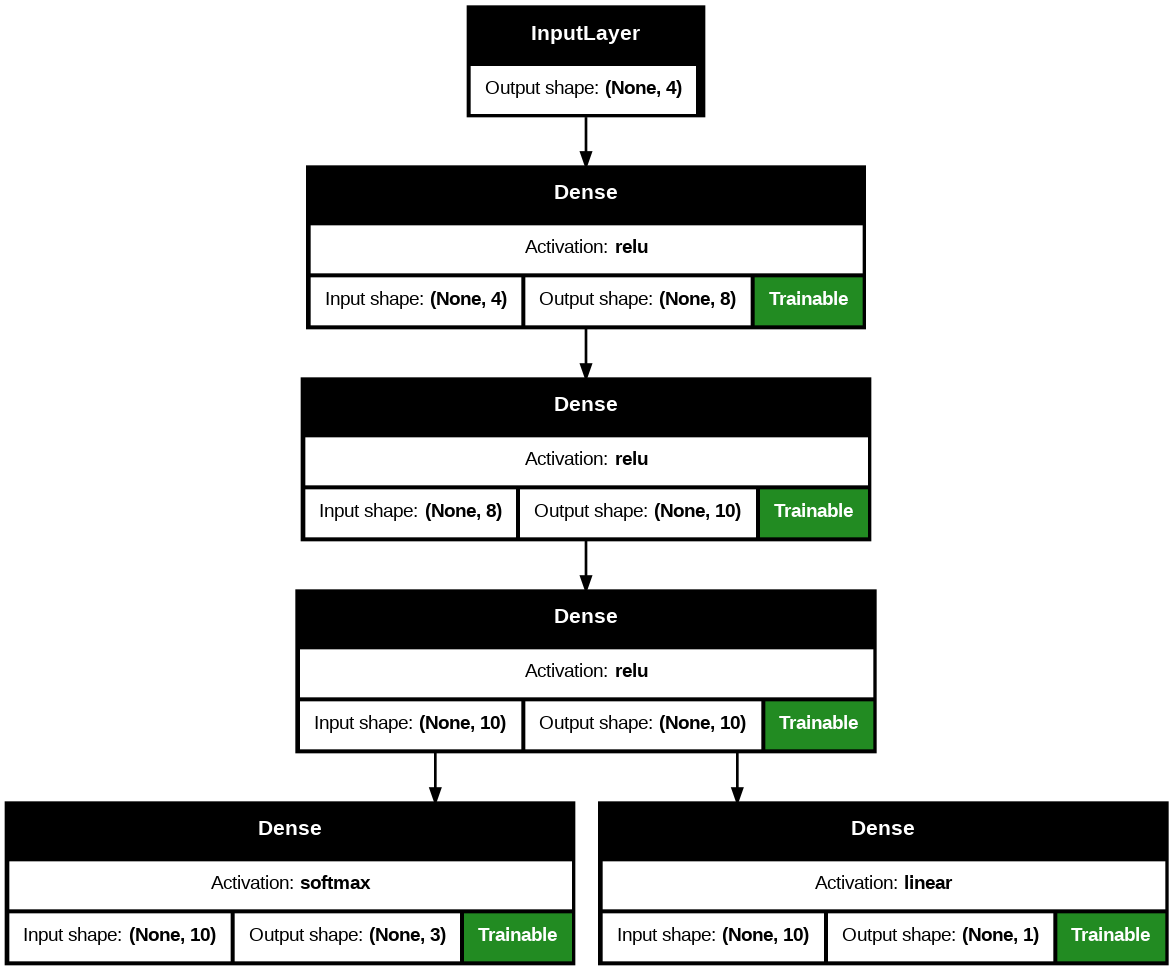

In [23]:
tf.keras.utils.plot_model(model,to_file="syed.png",show_shapes=True,dpi=96,show_layer_activations=True,show_trainable=True)

In [24]:
model.compile(optimizer='adam',loss={'outputs1':'categorical_crossentropy','outputs2':'mse'},metrics={'outputs1':'accuracy','outputs2':'mse'})

In [25]:
model.fit(X_train,{'outputs1':y_train,'outputs2':y_synthetic_train},epochs=100,batch_size=5,verbose=1)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.6125 - outputs1_accuracy: 0.2250 - outputs1_loss: 1.1441 - outputs2_loss: 0.4684 - outputs2_mse: 0.4684
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3430 - outputs1_accuracy: 0.4815 - outputs1_loss: 1.0607 - outputs2_loss: 0.2823 - outputs2_mse: 0.2823 
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1696 - outputs1_accuracy: 0.5251 - outputs1_loss: 0.9863 - outputs2_loss: 0.1833 - outputs2_mse: 0.1833 
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0884 - outputs1_accuracy: 0.5709 - outputs1_loss: 0.9278 - outputs2_loss: 0.1606 - outputs2_mse: 0.1606
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0351 - outputs1_accuracy: 0.6187 - outputs1_loss: 0.8938 - outputs2_loss: 0.1412 - outputs2_mse: 0.1412 
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9554 - outputs1_accuracy: 0.6429 - outputs1_loss: 0.8118 - outputs2_loss: 0.1436 - outputs2_mse: 0.1436 
Epoch 

In [26]:
scores = model.evaluate(X_test,{'outputs1':y_test,'outputs2':y_synthetic_test})
print("Accracy : ",scores[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - loss: 0.1201 - outputs1_accuracy: 1.0000 - outputs1_loss: 0.0367 - outputs2_loss: 0.0835 - outputs2_mse: 0.0835
Accracy :  0.03665478900074959
